In [1]:
# ==========================================
# 01_build_labels.ipynb
# Build clean T80 labels table
# ==========================================

import os
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", 200)
pd.set_option("display.max_rows", 200)

# Correct project directory
WORK_DIR = r"C:\Users\khanm\OneDrive\Desktop\3rd model 18-03-2026"

RAW_FILE = os.path.join(
    WORK_DIR,
    "Perovskite_database_content_all_data.csv"
)

ARTIFACT_DIR = os.path.join(WORK_DIR, "artifacts", "01_labels")
META_DIR = os.path.join(WORK_DIR, "metadata")
REPORT_DIR = os.path.join(WORK_DIR, "reports")
INTERIM_DIR = os.path.join(WORK_DIR, "interim")

for p in [ARTIFACT_DIR, META_DIR, REPORT_DIR, INTERIM_DIR]:
    os.makedirs(p, exist_ok=True)

print("WORK_DIR:", WORK_DIR)
print("RAW_FILE:", RAW_FILE)
print("RAW_FILE exists:", os.path.exists(RAW_FILE))
print("ARTIFACT_DIR:", ARTIFACT_DIR)

WORK_DIR: C:\Users\khanm\OneDrive\Desktop\3rd model 18-03-2026
RAW_FILE: C:\Users\khanm\OneDrive\Desktop\3rd model 18-03-2026\Perovskite_database_content_all_data.csv
RAW_FILE exists: True
ARTIFACT_DIR: C:\Users\khanm\OneDrive\Desktop\3rd model 18-03-2026\artifacts\01_labels


In [2]:
df = pd.read_csv(RAW_FILE, low_memory=False)

print("Raw shape:", df.shape)
df.head()

Raw shape: (43398, 410)


,Ref_ID,Ref_ID_temp,Ref_name_of_person_entering_the_data,Ref_data_entered_by_author,Ref_DOI_number,Ref_lead_author,Ref_publication_date,Ref_journal,Ref_part_of_initial_dataset,Ref_original_filename_data_upload,Ref_free_text_comment,Ref_internal_sample_id,Cell_stack_sequence,Cell_area_total,Cell_area_measured,Cell_number_of_cells_per_substrate,Cell_architecture,Cell_flexible,Cell_flexible_min_bending_radius,Cell_semitransparent,Cell_semitransparent_AVT,Cell_semitransparent_wavelength_range,Cell_semitransparent_raw_data,Module,Module_number_of_cells_in_module,Module_area_total,Module_area_effective,Module_JV_data_recalculated_per_cell,Substrate_stack_sequence,Substrate_thickness,Substrate_area,Substrate_supplier,Substrate_brand_name,Substrate_deposition_procedure,Substrate_surface_roughness_rms,Substrate_etching_procedure,Substrate_cleaning_procedure,ETL_stack_sequence,ETL_thickness,ETL_additives_compounds,ETL_additives_concentrations,ETL_deposition_procedure,ETL_deposition_aggregation_state_of_reactants,ETL_deposition_synthesis_atmosphere,ETL_deposition_synthesis_atmosphere_pressure_total,ETL_deposition_synthesis_atmosphere_pressure_partial,ETL_deposition_synthesis_atmosphere_relative_humidity,ETL_deposition_solvents,ETL_deposition_solvents_mixing_ratios,ETL_deposition_solvents_supplier,ETL_deposition_solvents_purity,ETL_deposition_reaction_solutions_compounds,ETL_deposition_reaction_solutions_compounds_supplier,ETL_deposition_reaction_solutions_compounds_purity,ETL_deposition_reaction_solutions_concentrations,ETL_deposition_reaction_solutions_volumes,ETL_deposition_reaction_solutions_age,ETL_deposition_reaction_solutions_temperature,ETL_deposition_substrate_temperature,ETL_deposition_thermal_annealing_temperature,ETL_deposition_thermal_annealing_time,ETL_deposition_thermal_annealing_atmosphere,ETL_storage_time_until_next_deposition_step,ETL_storage_atmosphere,ETL_storage_relative_humidity,ETL_surface_treatment_before_next_deposition_step,Perovskite_single_crystal,Perovskite_dimension_0D,Perovskite_dimension_2D,Perovskite_dimension_2D3D_mixture,Perovskite_dimension_3D,Perovskite_dimension_3D_with_2D_capping_layer,Perovskite_dimension_list_of_layers,Perovskite_composition_perovskite_ABC3_structure,Perovskite_composition_perovskite_inspired_structure,Perovskite_composition_a_ions,Perovskite_composition_a_ions_coefficients,Perovskite_composition_b_ions,Perovskite_composition_b_ions_coefficients,Perovskite_composition_c_ions,Perovskite_composition_c_ions_coefficients,Perovskite_composition_none_stoichiometry_components_in_excess,Perovskite_composition_short_form,Perovskite_composition_long_form,Perovskite_composition_assumption,Perovskite_composition_inorganic,Perovskite_composition_leadfree,Perovskite_additives_compounds,Perovskite_additives_concentrations,Perovskite_thickness,Perovskite_band_gap,Perovskite_band_gap_graded,Perovskite_band_gap_estimation_basis,Perovskite_pl_max,Perovskite_deposition_number_of_deposition_steps,Perovskite_deposition_procedure,Perovskite_deposition_aggregation_state_of_reactants,Perovskite_deposition_synthesis_atmosphere,Perovskite_deposition_synthesis_atmosphere_pressure_total,Perovskite_deposition_synthesis_atmosphere_pressure_partial,...,JV_default_Jsc_scan_direction,JV_default_FF_scan_direction,JV_default_PCE_scan_direction,JV_hysteresis_index,Stabilised_performance_measured,Stabilised_performance_procedure,Stabilised_performance_procedure_metrics,Stabilised_performance_measurement_time,Stabilised_performance_PCE,Stabilised_performance_Vmp,Stabilised_performance_Jmp,Stabilised_performance_link_raw_data,EQE_measured,EQE_light_bias,EQE_integrated_Jsc,EQE_link_raw_data,Stability_measured,Stability_protocol,Stability_average_over_n_number_of_cells,Stability_light_source_type,Stability_light_source_brand_name,Stability_light_source_simulator_class,Stability_light_intensity,Stability_light_spectra,Stability_light_wavelength_range,Stability_light_illumination_direction,Stability_light_load_condition,Stab

In [3]:
required_cols = [
    "Ref_DOI_number",
    "Ref_publication_date",
    "Cell_architecture",
    "Stability_protocol",
    "Encapsulation",
    "Stability_PCE_T80",
]

missing_required = [c for c in required_cols if c not in df.columns]

if missing_required:
    raise ValueError(f"Missing required columns: {missing_required}")

print("All required columns are present.")
required_cols

All required columns are present.


['Ref_DOI_number',
 'Ref_publication_date',
 'Cell_architecture',
 'Stability_protocol',
 'Encapsulation',
 'Stability_PCE_T80']

In [4]:
labels = df[required_cols].copy()

# keep original raw row identity
labels["raw_row_id"] = np.arange(len(df))

# move raw_row_id to front
front_cols = ["raw_row_id"] + required_cols
labels = labels[front_cols]

print("Initial labels shape:", labels.shape)
labels.head()

Initial labels shape: (43398, 7)


,raw_row_id,Ref_DOI_number,Ref_publication_date,Cell_architecture,Stability_protocol,Encapsulation,Stability_PCE_T80
0,0,10.1021/jp5126624,06/01/2015,nip,NaN,False,NaN
1,1,10.1021/jp5126624,06/01/2015,nip,NaN,False,NaN
2,2,10.1021/jp5126624,06/01/2015,nip,NaN,False,NaN
3,3,10.1021/jp5126624,06/01/2015,nip,NaN,False,NaN
4,4,10.1021/jp5126624,06/01/2015,nip,NaN,False,NaN


In [5]:
year_series = labels["Ref_publication_date"].astype(str).str.extract(r"(\d{4})")
labels["publication_year"] = pd.to_numeric(year_series[0], errors="coerce")

print("Publication year parsed.")
labels[["Ref_publication_date", "publication_year"]].head()

Publication year parsed.


,Ref_publication_date,publication_year
0,06/01/2015,2015
1,06/01/2015,2015
2,06/01/2015,2015
3,06/01/2015,2015
4,06/01/2015,2015


In [6]:
labels["T80_raw"] = labels["Stability_PCE_T80"]

# numeric coercion
labels["T80_clean"] = pd.to_numeric(labels["Stability_PCE_T80"], errors="coerce")

# enforce finite positive T80
labels.loc[~np.isfinite(labels["T80_clean"]), "T80_clean"] = np.nan
labels.loc[labels["T80_clean"] <= 0, "T80_clean"] = np.nan

# log1p target
labels["T80_log1p"] = np.log1p(labels["T80_clean"])

print("Raw non-missing T80:", labels["T80_raw"].notna().sum())
print("Numeric valid T80:", labels["T80_clean"].notna().sum())
print("Log target valid:", labels["T80_log1p"].notna().sum())

Raw non-missing T80: 1839
Numeric valid T80: 1837
Log target valid: 1837


In [7]:
labels_t80 = labels[labels["T80_clean"].notna()].copy()

print("Rows after valid T80 filter:", len(labels_t80))
labels_t80.head()

Rows after valid T80 filter: 1837


,raw_row_id,Ref_DOI_number,Ref_publication_date,Cell_architecture,Stability_protocol,Encapsulation,Stability_PCE_T80,publication_year,T80_raw,T80_clean,T80_log1p
27,27,10.1039/c9ta01893j,20/03/2019,nip,ISOS-L-1,False,200.0,2019,200.0,200.0,5.303305
45,45,10.1002/aenm.201803587,06/03/2019,nip,ISOS-L-1,False,150.0,2019,150.0,150.0,5.017280
59,59,10.1038/ncomms15330,12/06/2017,pin,ISOS-D-2,False,450.0,2017,450.0,450.0,6.111467
79,79,10.1021/acs.jpcc.5b06269,24/08/2015,pin,ISOS-L-1,False,0.4,2015,0.4,0.4,0.336472
97,97,10.1039/c8qi00309b,14/05/2018,pin,ISOS-D-1I,False,216.0,2018,216.0,216.0,5.379897


In [8]:
before = len(labels_t80)

labels_t80 = labels_t80[labels_t80["Ref_DOI_number"].notna()].copy()

after = len(labels_t80)

print("Rows before DOI filter:", before)
print("Rows after DOI filter:", after)
print("Dropped due to missing DOI:", before - after)

Rows before DOI filter: 1837
Rows after DOI filter: 1837
Dropped due to missing DOI: 0


In [9]:
string_cols = [
    "Ref_DOI_number",
    "Cell_architecture",
    "Stability_protocol",
    "Encapsulation",
]

for col in string_cols:
    labels_t80[col] = (
        labels_t80[col]
        .astype(str)
        .str.strip()
        .replace({"nan": np.nan, "None": np.nan, "": np.nan})
    )

print("String cleanup complete.")
labels_t80[string_cols].head()

String cleanup complete.


,Ref_DOI_number,Cell_architecture,Stability_protocol,Encapsulation
27,10.1039/c9ta01893j,nip,ISOS-L-1,False
45,10.1002/aenm.201803587,nip,ISOS-L-1,False
59,10.1038/ncomms15330,pin,ISOS-D-2,False
79,10.1021/acs.jpcc.5b06269,pin,ISOS-L-1,False
97,10.1039/c8qi00309b,pin,ISOS-D-1I,False


In [10]:
# ============================================================
# REMOVE TWO AUDITED ERRONEOUS T80 RECORDS
# ============================================================

bad_t80_rows = [38777, 38778]

print("Rows before removal:", len(labels_t80))

labels_t80 = labels_t80[
    ~labels_t80["raw_row_id"].isin(bad_t80_rows)
].copy()

print("Rows after removal:", len(labels_t80))

# confirm they are gone
print(
    labels_t80[
        labels_t80["raw_row_id"].isin(bad_t80_rows)
    ]
)

Rows before removal: 1837
Rows after removal: 1835
Empty DataFrame
Columns: [raw_row_id, Ref_DOI_number, Ref_publication_date, Cell_architecture, Stability_protocol, Encapsulation, Stability_PCE_T80, publication_year, T80_raw, T80_clean, T80_log1p]
Index: []


In [11]:
target_summary = {
    "n_rows_final": int(len(labels_t80)),
    "n_unique_doi": int(labels_t80["Ref_DOI_number"].nunique()),
    "n_missing_doi": int(labels_t80["Ref_DOI_number"].isna().sum()),
    "t80_min": float(labels_t80["T80_clean"].min()),
    "t80_median": float(labels_t80["T80_clean"].median()),
    "t80_mean": float(labels_t80["T80_clean"].mean()),
    "t80_max": float(labels_t80["T80_clean"].max()),
    "t80_log1p_min": float(labels_t80["T80_log1p"].min()),
    "t80_log1p_median": float(labels_t80["T80_log1p"].median()),
    "t80_log1p_mean": float(labels_t80["T80_log1p"].mean()),
    "t80_log1p_max": float(labels_t80["T80_log1p"].max()),
}

target_summary

{'n_rows_final': 1835,
 'n_unique_doi': 964,
 'n_missing_doi': 0,
 't80_min': 0.02,
 't80_median': 150.0,
 't80_mean': 361.1036102614289,
 't80_max': 8400.0,
 't80_log1p_min': 0.019802627296179712,
 't80_log1p_median': 5.017279836814924,
 't80_log1p_mean': 4.672327661016682,
 't80_log1p_max': 9.036106025364846}

In [12]:
arch_counts = (
    labels_t80["Cell_architecture"]
    .fillna("MISSING")
    .value_counts(dropna=False)
    .rename_axis("Cell_architecture")
    .reset_index(name="n_rows")
)

arch_counts.to_csv(os.path.join(REPORT_DIR, "01_architecture_counts_in_labels.csv"), index=False)

arch_counts.head(20)

,Cell_architecture,n_rows
0,nip,1266
1,pin,567
2,Unknown,1
3,Back contacted,1


In [13]:
doi_counts = labels_t80["Ref_DOI_number"].value_counts()

doi_summary = {
    "unique_dois": int(doi_counts.shape[0]),
    "mean_rows_per_doi": float(doi_counts.mean()),
    "median_rows_per_doi": float(doi_counts.median()),
    "max_rows_per_doi": int(doi_counts.max()),
    "singleton_dois": int((doi_counts == 1).sum()),
}

doi_summary

{'unique_dois': 964,
 'mean_rows_per_doi': 1.9035269709543567,
 'median_rows_per_doi': 1.0,
 'max_rows_per_doi': 12,
 'singleton_dois': 489}

Unique DOI groups: 964
Maximum devices per DOI: 12
Singleton DOI groups: 489


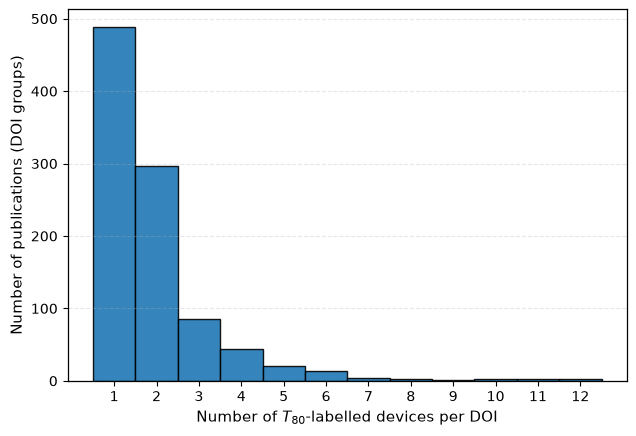


Figure saved successfully:
C:\Users\khanm\OneDrive\Desktop\3rd model 18-03-2026\ipynb_checkpoints\figures\doi_counts_final_T80.png


In [30]:
# ============================================================
# DOI DEVICE-COUNT DISTRIBUTION — FINAL T80 DATASET
# ============================================================

import os
import numpy as np
import matplotlib.pyplot as plt

# ------------------------------------------------------------
# Output folder
# ------------------------------------------------------------
ARTIFACT_DIR = os.path.join(os.getcwd(), "figures")
os.makedirs(ARTIFACT_DIR, exist_ok=True)

# ------------------------------------------------------------
# DOI counts
# ------------------------------------------------------------
doi_counts = labels_t80["Ref_DOI_number"].value_counts()

print(f"Unique DOI groups: {len(doi_counts)}")
print(f"Maximum devices per DOI: {doi_counts.max()}")
print(f"Singleton DOI groups: {(doi_counts == 1).sum()}")

# ------------------------------------------------------------
# Plot
# ------------------------------------------------------------
fig, ax = plt.subplots(figsize=(6.5, 4.5))

bins = np.arange(0.5, doi_counts.max() + 1.5, 1)

ax.hist(
    doi_counts.values,
    bins=bins,
    edgecolor="black",
    linewidth=1.0,
    alpha=0.9
)

ax.set_xlabel(
    r"Number of $T_{80}$-labelled devices per DOI",
    fontsize=11
)

ax.set_ylabel(
    "Number of publications (DOI groups)",
    fontsize=11
)

ax.set_xticks(range(1, int(doi_counts.max()) + 1))
ax.tick_params(axis="both", labelsize=10)

ax.grid(
    axis="y",
    linestyle="--",
    alpha=0.3
)

fig.tight_layout()

# ------------------------------------------------------------
# Save
# ------------------------------------------------------------
save_path = os.path.join(
    ARTIFACT_DIR,
    "doi_counts_final_T80.png"
)

fig.savefig(
    save_path,
    dpi=600,
    bbox_inches="tight"
)

plt.show()

# ------------------------------------------------------------
# Confirm saved location
# ------------------------------------------------------------
print("\nFigure saved successfully:")
print(os.path.abspath(save_path))

Dataset shape: (1835, 11)
Columns used:
  - T80_log1p
  - Ref_DOI_number

FINAL DATASET CHECK
-------------------
Number of devices: 1,835
Unique DOI groups: 964
Maximum devices per DOI: 12
Singleton DOI groups: 489
Minimum T80: 0.020 h
Median T80: 150.0 h
Maximum T80: 8400.0 h
25th percentile ln(1+T80): 3.61
Median ln(1+T80): 5.02
75th percentile ln(1+T80): 6.15


C:\Users\khanm\AppData\Local\Temp\ipykernel_19008\2870894968.py:346: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


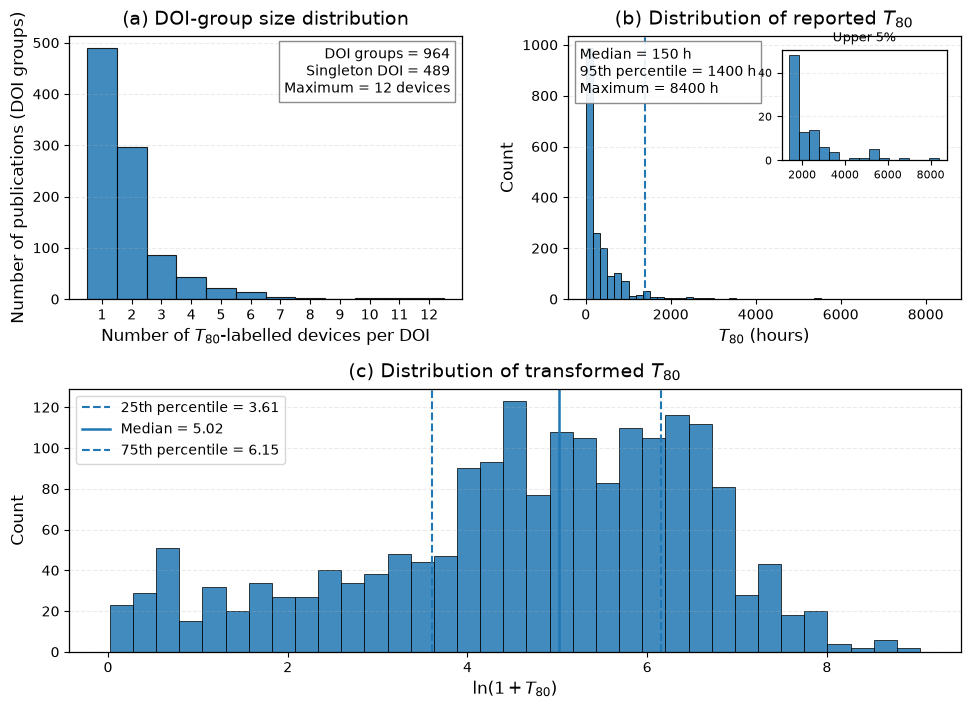


FIGURE SAVED SUCCESSFULLY
-------------------------
PNG: C:\Users\khanm\OneDrive\Desktop\3rd model 18-03-2026\ipynb_checkpoints\figures\Figure1_FINAL.png
PDF: C:\Users\khanm\OneDrive\Desktop\3rd model 18-03-2026\ipynb_checkpoints\figures\Figure1_FINAL.pdf


In [32]:
# ============================================================
# FIGURE 1 — FINAL PUBLICATION VERSION
# Same layout style as Figure 2
#
# (a) Devices per DOI
# (b) Raw T80 distribution + high-stability inset
# (c) ln(1 + T80) distribution
# ============================================================

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from mpl_toolkits.axes_grid1.inset_locator import inset_axes

# ------------------------------------------------------------
# LOAD FINAL AUDITED T80 DATASET
# ------------------------------------------------------------

LABEL_FILE = os.path.join(
    WORK_DIR,
    "interim",
    "t80_labels.parquet"
)

labels_final = pd.read_parquet(LABEL_FILE)

print("Dataset shape:", labels_final.shape)
print("Columns used:")

# ------------------------------------------------------------
# CHECK REQUIRED COLUMNS
# ------------------------------------------------------------

if "T80_log1p" not in labels_final.columns:
    raise KeyError("Column 'T80_log1p' not found in final label file.")

if "Ref_DOI_number" not in labels_final.columns:
    raise KeyError("Column 'Ref_DOI_number' not found in final label file.")

print("  - T80_log1p")
print("  - Ref_DOI_number")

# ------------------------------------------------------------
# PREPARE DATA
# ------------------------------------------------------------

# Final transformed target
log_data = pd.to_numeric(
    labels_final["T80_log1p"],
    errors="coerce"
).dropna()

# Recover raw T80 from ln(1 + T80)
t80_hours = np.expm1(log_data)

# DOI group-size distribution
doi_counts = (
    labels_final["Ref_DOI_number"]
    .dropna()
    .value_counts()
)

# Percentiles in transformed space
q25 = log_data.quantile(0.25)
median_val = log_data.median()
q75 = log_data.quantile(0.75)

# Raw T80 95th percentile for inset/high-stability region
t80_q95 = t80_hours.quantile(0.95)

# ------------------------------------------------------------
# PRINT AUDIT
# ------------------------------------------------------------

print("\nFINAL DATASET CHECK")
print("-------------------")
print(f"Number of devices: {len(log_data):,}")
print(f"Unique DOI groups: {len(doi_counts):,}")
print(f"Maximum devices per DOI: {doi_counts.max()}")
print(f"Singleton DOI groups: {(doi_counts == 1).sum()}")
print(f"Minimum T80: {t80_hours.min():.3f} h")
print(f"Median T80: {t80_hours.median():.1f} h")
print(f"Maximum T80: {t80_hours.max():.1f} h")
print(f"25th percentile ln(1+T80): {q25:.2f}")
print(f"Median ln(1+T80): {median_val:.2f}")
print(f"75th percentile ln(1+T80): {q75:.2f}")

# ------------------------------------------------------------
# FIGURE LAYOUT — SAME STRUCTURE AS FIGURE 2
# ------------------------------------------------------------

fig = plt.figure(figsize=(11.5, 8.0))

gs = fig.add_gridspec(
    2, 2,
    height_ratios=[1, 1.0],
    hspace=0.34,
    wspace=0.27
)

ax_a = fig.add_subplot(gs[0, 0])
ax_b = fig.add_subplot(gs[0, 1])
ax_c = fig.add_subplot(gs[1, :])

# ============================================================
# PANEL (a) — DOI GROUP SIZE
# ============================================================

bins_doi = np.arange(
    0.5,
    doi_counts.max() + 1.5,
    1
)

ax_a.hist(
    doi_counts.values,
    bins=bins_doi,
    edgecolor="black",
    linewidth=0.8,
    alpha=0.85
)

ax_a.set_title(
    "(a) DOI-group size distribution",
    fontsize=14,
    pad=8
)

ax_a.set_xlabel(
    r"Number of $T_{80}$-labelled devices per DOI",
    fontsize=12
)

ax_a.set_ylabel(
    "Number of publications (DOI groups)",
    fontsize=12
)

ax_a.set_xticks(
    range(1, int(doi_counts.max()) + 1)
)

ax_a.tick_params(
    axis="both",
    labelsize=10
)

ax_a.grid(
    axis="y",
    linestyle="--",
    alpha=0.25
)

# Information box
ax_a.text(
    0.97,
    0.96,
    f"DOI groups = {len(doi_counts)}\n"
    f"Singleton DOI = {(doi_counts == 1).sum()}\n"
    f"Maximum = {doi_counts.max()} devices",
    transform=ax_a.transAxes,
    ha="right",
    va="top",
    fontsize=10,
    bbox=dict(
        boxstyle="square,pad=0.35",
        facecolor="white",
        edgecolor="gray",
        alpha=0.9
    )
)

# ============================================================
# PANEL (b) — RAW T80 DISTRIBUTION
# ============================================================

ax_b.hist(
    t80_hours,
    bins=50,
    edgecolor="black",
    linewidth=0.7,
    alpha=0.85
)

ax_b.axvline(
    t80_q95,
    linestyle="--",
    linewidth=1.5
)

ax_b.set_title(
    r"(b) Distribution of reported $T_{80}$",
    fontsize=14,
    pad=8
)

ax_b.set_xlabel(
    r"$T_{80}$ (hours)",
    fontsize=12
)

ax_b.set_ylabel(
    "Count",
    fontsize=12
)

ax_b.tick_params(
    axis="both",
    labelsize=10
)

ax_b.grid(
    axis="y",
    linestyle="--",
    alpha=0.25
)

# ------------------------------------------------------------
# INSET — HIGH-LIFETIME REGION
# ------------------------------------------------------------

ax_inset = inset_axes(
    ax_b,
    width="42%",
    height="42%",
    loc="upper right",
    borderpad=1.0
)

high_data = t80_hours[t80_hours >= t80_q95]

ax_inset.hist(
    high_data,
    bins=15,
    edgecolor="black",
    linewidth=0.6,
    alpha=0.85
)

ax_inset.set_title(
    "Upper 5%",
    fontsize=9
)

ax_inset.tick_params(
    axis="both",
    labelsize=8
)

ax_inset.grid(
    axis="y",
    linestyle="--",
    alpha=0.20
)

# Small statistics box
ax_b.text(
    0.03,
    0.96,
    f"Median = {t80_hours.median():.0f} h\n"
    f"95th percentile = {t80_q95:.0f} h\n"
    f"Maximum = {t80_hours.max():.0f} h",
    transform=ax_b.transAxes,
    ha="left",
    va="top",
    fontsize=10,
    bbox=dict(
        boxstyle="square,pad=0.35",
        facecolor="white",
        edgecolor="gray",
        alpha=0.9
    )
)

# ============================================================
# PANEL (c) — ln(1 + T80) DISTRIBUTION
# ============================================================

ax_c.hist(
    log_data,
    bins=35,
    edgecolor="black",
    linewidth=0.6,
    alpha=0.85
)

ax_c.axvline(
    q25,
    linestyle="--",
    linewidth=1.5,
    label=f"25th percentile = {q25:.2f}"
)

ax_c.axvline(
    median_val,
    linestyle="-",
    linewidth=1.8,
    label=f"Median = {median_val:.2f}"
)

ax_c.axvline(
    q75,
    linestyle="--",
    linewidth=1.5,
    label=f"75th percentile = {q75:.2f}"
)

ax_c.set_title(
    r"(c) Distribution of transformed $T_{80}$",
    fontsize=14,
    pad=8
)

ax_c.set_xlabel(
    r"$\ln(1 + T_{80})$",
    fontsize=12
)

ax_c.set_ylabel(
    "Count",
    fontsize=12
)

ax_c.tick_params(
    axis="both",
    labelsize=10
)

ax_c.grid(
    axis="y",
    linestyle="--",
    alpha=0.25
)

ax_c.legend(
    loc="upper left",
    fontsize=10,
    frameon=True
)

# ------------------------------------------------------------
# FINAL LAYOUT
# ------------------------------------------------------------

plt.tight_layout()

# ------------------------------------------------------------
# SAVE
# ------------------------------------------------------------

FIG_DIR = os.path.join(
    os.getcwd(),
    "figures"
)

os.makedirs(
    FIG_DIR,
    exist_ok=True
)

png_path = os.path.join(
    FIG_DIR,
    "Figure1_FINAL.png"
)

pdf_path = os.path.join(
    FIG_DIR,
    "Figure1_FINAL.pdf"
)

fig.savefig(
    png_path,
    dpi=600,
    bbox_inches="tight"
)

fig.savefig(
    pdf_path,
    bbox_inches="tight"
)

plt.show()

# ------------------------------------------------------------
# CONFIRM SAVE
# ------------------------------------------------------------

print("\nFIGURE SAVED SUCCESSFULLY")
print("-------------------------")
print("PNG:", os.path.abspath(png_path))
print("PDF:", os.path.abspath(pdf_path))

In [15]:
final_cols = [
    "raw_row_id",
    "Ref_DOI_number",
    "Ref_publication_date",
    "publication_year",
    "Cell_architecture",
    "Stability_protocol",
    "Encapsulation",
    "Stability_PCE_T80",
    "T80_raw",
    "T80_clean",
    "T80_log1p",
]

labels_t80 = labels_t80[final_cols].copy()

print("Final labels_t80 shape:", labels_t80.shape)
labels_t80.head()

Final labels_t80 shape: (1835, 11)


,raw_row_id,Ref_DOI_number,Ref_publication_date,publication_year,Cell_architecture,Stability_protocol,Encapsulation,Stability_PCE_T80,T80_raw,T80_clean,T80_log1p
27,27,10.1039/c9ta01893j,20/03/2019,2019,nip,ISOS-L-1,False,200.0,200.0,200.0,5.303305
45,45,10.1002/aenm.201803587,06/03/2019,2019,nip,ISOS-L-1,False,150.0,150.0,150.0,5.017280
59,59,10.1038/ncomms15330,12/06/2017,2017,pin,ISOS-D-2,False,450.0,450.0,450.0,6.111467
79,79,10.1021/acs.jpcc.5b06269,24/08/2015,2015,pin,ISOS-L-1,False,0.4,0.4,0.4,0.336472
97,97,10.1039/c8qi00309b,14/05/2018,2018,pin,ISOS-D-1I,False,216.0,216.0,216.0,5.379897


In [16]:
# ============================================================
# REVIEWER 1 COMMENT 6 — AUDIT EXTREME LOW T80 VALUES
# ============================================================

extreme_low = labels_t80[
    labels_t80["T80_clean"] < 0.1
].copy()

print("Number of T80 values < 0.1 h:", len(extreme_low))

display(
    extreme_low[
        [
            "raw_row_id",
            "Ref_DOI_number",
            "Ref_publication_date",
            "Cell_architecture",
            "Stability_protocol",
            "Stability_PCE_T80",
            "T80_raw",
            "T80_clean"
        ]
    ].sort_values("T80_clean")
)

Number of T80 values < 0.1 h: 4


,raw_row_id,Ref_DOI_number,Ref_publication_date,Cell_architecture,Stability_protocol,Stability_PCE_T80,T80_raw,T80_clean
19495,19495,10.1039/c6ta02999j,17/05/2016,nip,ISOS-L-1,0.020,0.020,0.020
36629,36629,10.1002/adma.201505279,16/02/2016,pin,ISOS-L-2,0.025,0.025,0.025
43070,43070,10.1039/c8ra00809d,16/04/2018,pin,ISOS-D-1,0.030,0.030,0.030
37206,37206,10.1002/aenm.201601055,08/07/2016,nip,ISOS-L-1I,0.050,0.050,0.050


In [17]:
# ============================================================
# REVIEWER 1 COMMENT 6 — RAW-DATABASE AUDIT OF EXTREME T80
# ============================================================

audit_ids = extreme_low["raw_row_id"].astype(int).tolist()

# Make raw_row_id explicit in the raw database
raw_audit = df.copy()
raw_audit["raw_row_id"] = np.arange(len(raw_audit))

# Useful contextual fields, if available
candidate_cols = [
    "raw_row_id",
    "Ref_DOI_number",
    "Ref_publication_date",
    "Cell_architecture",
    "Stability_protocol",
    "Stability_PCE_T80",
    "Stability_time_total_exposure",
    "Stability_PCE_end_of_experiment",
    "Stability_temperature_range",
    "Stability_relative_humidity_average_value",
    "Stability_light_intensity",
    "Stability_potential_bias_load_condition"
]

audit_cols = [c for c in candidate_cols if c in raw_audit.columns]

extreme_raw_audit = (
    raw_audit.loc[
        raw_audit["raw_row_id"].isin(audit_ids),
        audit_cols
    ]
    .sort_values("Stability_PCE_T80")
)

display(extreme_raw_audit)

,raw_row_id,Ref_DOI_number,Ref_publication_date,Cell_architecture,Stability_protocol,Stability_PCE_T80,Stability_time_total_exposure,Stability_PCE_end_of_experiment,Stability_temperature_range,Stability_relative_humidity_average_value,Stability_light_intensity,Stability_potential_bias_load_condition
19495,19495,10.1039/c6ta02999j,17/05/2016,nip,ISOS-L-1,0.020,1.00,9.0,20.0; 20.0,40.0,100.0,Open circuit
36629,36629,10.1002/adma.201505279,16/02/2016,pin,ISOS-L-2,0.025,2.00,0.0,100.0; 100.0,NaN,100.0,MPPT
43070,43070,10.1039/c8ra00809d,16/04/2018,pin,ISOS-D-1,0.030,1.83,3.0,25.0; 25.0,50.0,0.0,Open circuit
37206,37206,10.1002/aenm.201601055,08/07/2016,nip,ISOS-L-1I,0.050,5.00,0.0,45.0; 45.0,NaN,100.0,Constant potential


In [18]:
import sys
print(sys.executable)

C:\Users\khanm\anaconda3\envs\t80_ml\python.exe


In [19]:
%pip install pyarrow

Note: you may need to restart the kernel to use updated packages.


In [20]:
parquet_path = os.path.join(INTERIM_DIR, "t80_labels.parquet")
csv_path = os.path.join(INTERIM_DIR, "t80_labels.csv")

labels_t80.to_parquet(parquet_path, index=False)
labels_t80.to_csv(csv_path, index=False)

print("Saved:", parquet_path)
print("Saved:", csv_path)

Saved: C:\Users\khanm\OneDrive\Desktop\3rd model 18-03-2026\interim\t80_labels.parquet
Saved: C:\Users\khanm\OneDrive\Desktop\3rd model 18-03-2026\interim\t80_labels.csv


In [21]:
label_card = {
    "notebook": "01_build_labels.ipynb",
    "source_file": RAW_FILE,
    "target_definition": {
        "raw_target_column": "Stability_PCE_T80",
        "clean_target_column": "T80_clean",
        "log_target_column": "T80_log1p",
        "cleaning_rules": [
            "coerce target to numeric",
            "remove non-finite values",
            "remove T80 <= 0",
            "remove rows with missing DOI"
        ]
    },
    "row_counts": {
        "raw_rows": int(len(df)),
        "raw_non_missing_t80": int(pd.to_numeric(df["Stability_PCE_T80"], errors="coerce").notna().sum()),
        "final_rows_after_cleaning": int(len(labels_t80))
    },
    "doi_summary": doi_summary,
    "target_summary": target_summary,
    "saved_files": {
        "parquet": parquet_path,
        "csv": csv_path
    }
}

label_card_path = os.path.join(META_DIR, "label_card.json")

with open(label_card_path, "w", encoding="utf-8") as f:
    json.dump(label_card, f, indent=4)

print("Saved:", label_card_path)

Saved: C:\Users\khanm\OneDrive\Desktop\3rd model 18-03-2026\metadata\label_card.json


In [22]:
pd.DataFrame([target_summary]).to_csv(
    os.path.join(REPORT_DIR, "01_target_summary.csv"), index=False
)

pd.DataFrame([doi_summary]).to_csv(
    os.path.join(REPORT_DIR, "01_doi_summary_labels.csv"), index=False
)

print("Quick report tables saved.")

Quick report tables saved.


In [23]:
print("========== LABEL BUILD SUMMARY ==========")
print("Raw dataset rows:", len(df))
print("Final label rows:", len(labels_t80))
print("Unique DOI groups:", labels_t80["Ref_DOI_number"].nunique())
print("Missing DOI rows in final labels:", labels_t80["Ref_DOI_number"].isna().sum())
print("T80_clean missing:", labels_t80["T80_clean"].isna().sum())
print("T80_log1p missing:", labels_t80["T80_log1p"].isna().sum())
print("Saved to interim and metadata folders.")

========== LABEL BUILD SUMMARY ==========
Raw dataset rows: 43398
Final label rows: 1835
Unique DOI groups: 964
Missing DOI rows in final labels: 0
T80_clean missing: 0
T80_log1p missing: 0
Saved to interim and metadata folders.


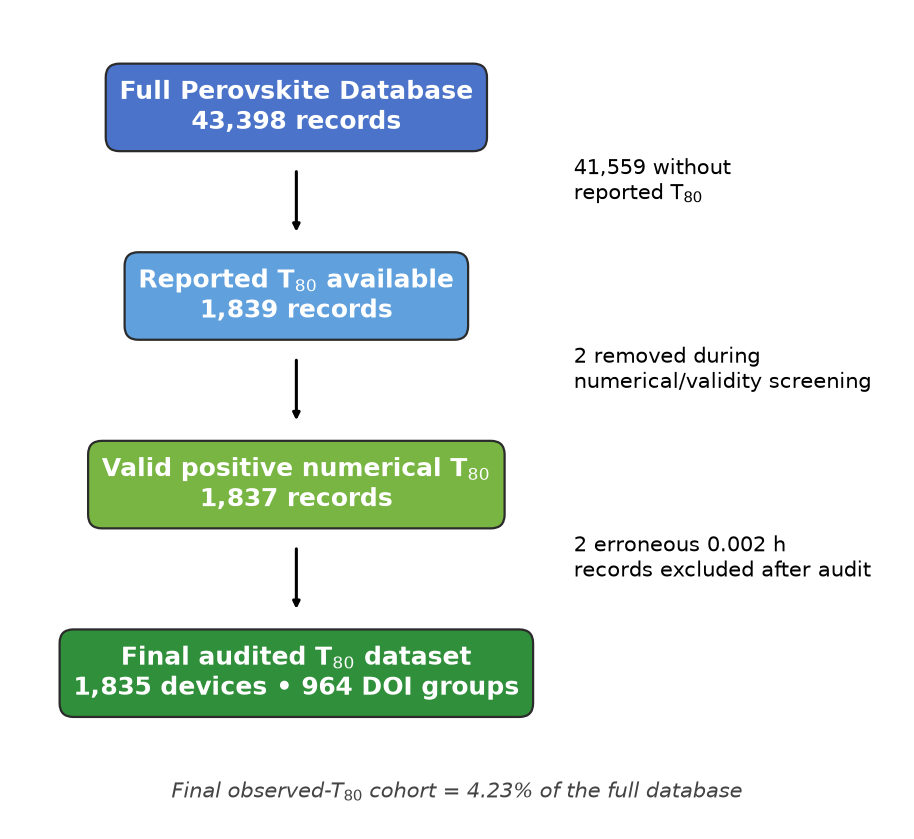

In [24]:
# ============================================================
# FIGURE S2(a) — HIGH-RES T80 DATASET CONSTRUCTION FLOW
# ============================================================

import matplotlib.pyplot as plt
import os

raw_rows = 43398
reported_t80 = 1839
valid_numeric_t80 = 1837
final_audited_t80 = 1835
final_doi = 964

fig, ax = plt.subplots(figsize=(9.5, 8.5))
ax.set_xlim(0, 10)
ax.set_ylim(0, 10)
ax.axis("off")

# Box positions
y_positions = [8.8, 6.5, 4.2, 1.9]

box_text = [
    ("Full Perovskite Database", "43,398 records"),
    ("Reported T$_{80}$ available", "1,839 records"),
    ("Valid positive numerical T$_{80}$", "1,837 records"),
    ("Final audited T$_{80}$ dataset", "1,835 devices • 964 DOI groups"),
]

box_colors = ["#4A73C9", "#5FA0DD", "#78B542", "#2F8F3A"]

for y, (title, count), color in zip(y_positions, box_text, box_colors):
    ax.text(
        3.2, y,
        f"{title}\n{count}",
        ha="center",
        va="center",
        fontsize=18,
        fontweight="bold",
        color="white",
        bbox=dict(
            boxstyle="round,pad=0.55",
            facecolor=color,
            edgecolor="#2b2b2b",
            linewidth=1.6
        )
    )

# Vertical arrows
x_arrow = 3.2
for y1, y2 in zip(y_positions[:-1], y_positions[1:]):
    ax.annotate(
        "",
        xy=(x_arrow, y2 + 0.75),
        xytext=(x_arrow, y1 - 0.75),
        arrowprops=dict(
            arrowstyle="-|>",
            lw=2.2,
            color="black"
        )
    )

# Side annotations
ax.text(
    6.3, 7.9,
    "41,559 without\nreported T$_{80}$",
    fontsize=15,
    ha="left",
    va="center"
)

ax.text(
    6.3, 5.6,
    "2 removed during\nnumerical/validity screening",
    fontsize=15,
    ha="left",
    va="center"
)

ax.text(
    6.3, 3.3,
    "2 erroneous 0.002 h\nrecords excluded after audit",
    fontsize=15,
    ha="left",
    va="center"
)

retained_pct = final_audited_t80 / raw_rows * 100

ax.text(
    5.0, 0.45,
    f"Final observed-T$_{{80}}$ cohort = {retained_pct:.2f}% of the full database",
    ha="center",
    va="center",
    fontsize=15,
    style="italic",
    color="#444444"
)

plt.tight_layout()

plt.savefig(
    os.path.join(ARTIFACT_DIR, "FigS2a_T80_data_flow.png"),
    dpi=900,
    bbox_inches="tight",
    facecolor="white"
)

plt.savefig(
    os.path.join(ARTIFACT_DIR, "FigS2a_T80_data_flow.pdf"),
    bbox_inches="tight",
    facecolor="white"
)

plt.show()

C:\Users\khanm\AppData\Local\Temp\ipykernel_19008\2083930787.py:13: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


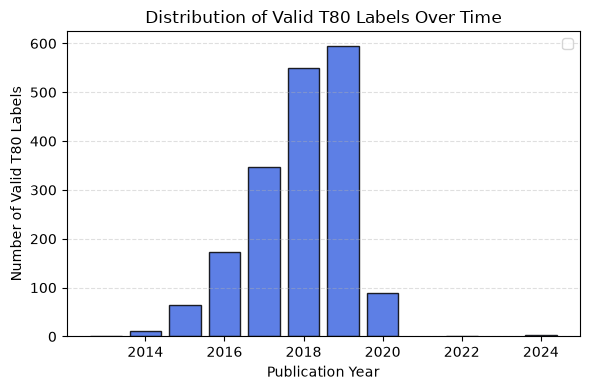

In [25]:
year_counts = labels_t80["publication_year"].value_counts().sort_index()

plt.figure(figsize=(6,4))


plt.bar(year_counts.index.astype(int),year_counts.values,color="royalblue",edgecolor="black",alpha=0.85)


plt.xlabel("Publication Year")
plt.ylabel("Number of Valid T80 Labels")
plt.title("Distribution of Valid T80 Labels Over Time")

plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.4)
plt.tight_layout()

plt.savefig(os.path.join(ARTIFACT_DIR, "t80_year_trend.png"), dpi=600)
plt.show()

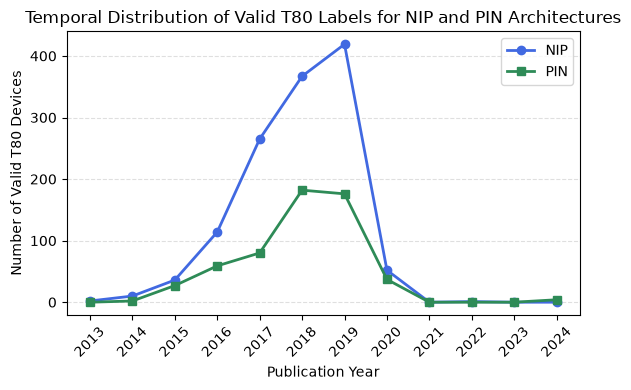

In [26]:
tmp = labels_t80.dropna(subset=["publication_year", "Cell_architecture"]).copy()

tmp["publication_year"] = tmp["publication_year"].astype(int)

tmp["arch_clean"] = (tmp["Cell_architecture"].astype(str).str.strip().str.lower())

tmp = tmp[tmp["arch_clean"].isin(["nip", "pin"])].copy()

arch_year_counts = (tmp.groupby(["publication_year", "arch_clean"]).size().unstack(fill_value=0).sort_index())

full_years = range(arch_year_counts.index.min(), arch_year_counts.index.max() + 1)
arch_year_counts = arch_year_counts.reindex(full_years, fill_value=0)

plt.figure(figsize=(6,4))

plt.plot( arch_year_counts.index,arch_year_counts["nip"],marker="o",linewidth=2,markersize=6,color="royalblue", label="NIP")

plt.plot(arch_year_counts.index,arch_year_counts["pin"],marker="s",linewidth=2,markersize=6,color="seagreen",label="PIN")

plt.xlabel("Publication Year")
plt.ylabel("Number of Valid T80 Devices")
plt.title("Temporal Distribution of Valid T80 Labels for NIP and PIN Architectures")

plt.xticks(arch_year_counts.index, rotation=45)
plt.grid(axis="y", linestyle="--", alpha=0.4)
plt.legend(frameon=True)

plt.tight_layout()

plt.savefig(os.path.join(ARTIFACT_DIR, "nip_pin_over_time.png"), dpi=600)
plt.show()

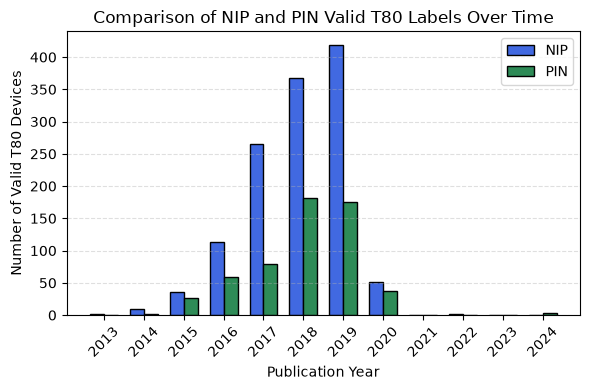

In [27]:
x = np.arange(len(arch_year_counts.index))
width = 0.35

plt.figure(figsize=(6,4))

plt.bar( x - width/2,arch_year_counts["nip"],width=width,color="royalblue", edgecolor="black",label="NIP")

plt.bar(x + width/2,arch_year_counts["pin"],width=width,color="seagreen",edgecolor="black",label="PIN")

plt.xlabel("Publication Year")
plt.ylabel("Number of Valid T80 Devices")
plt.title("Comparison of NIP and PIN Valid T80 Labels Over Time")

plt.xticks(x, arch_year_counts.index, rotation=45)

plt.grid(axis="y", linestyle="--", alpha=0.4)
plt.legend()

plt.tight_layout()

plt.savefig(os.path.join(ARTIFACT_DIR, "nip_vs_pin_final.png"), dpi=600)
plt.show()

findfont: Failed to find font weight semibold, now using 700.
findfont: Failed to find font weight semibold, now using 700.


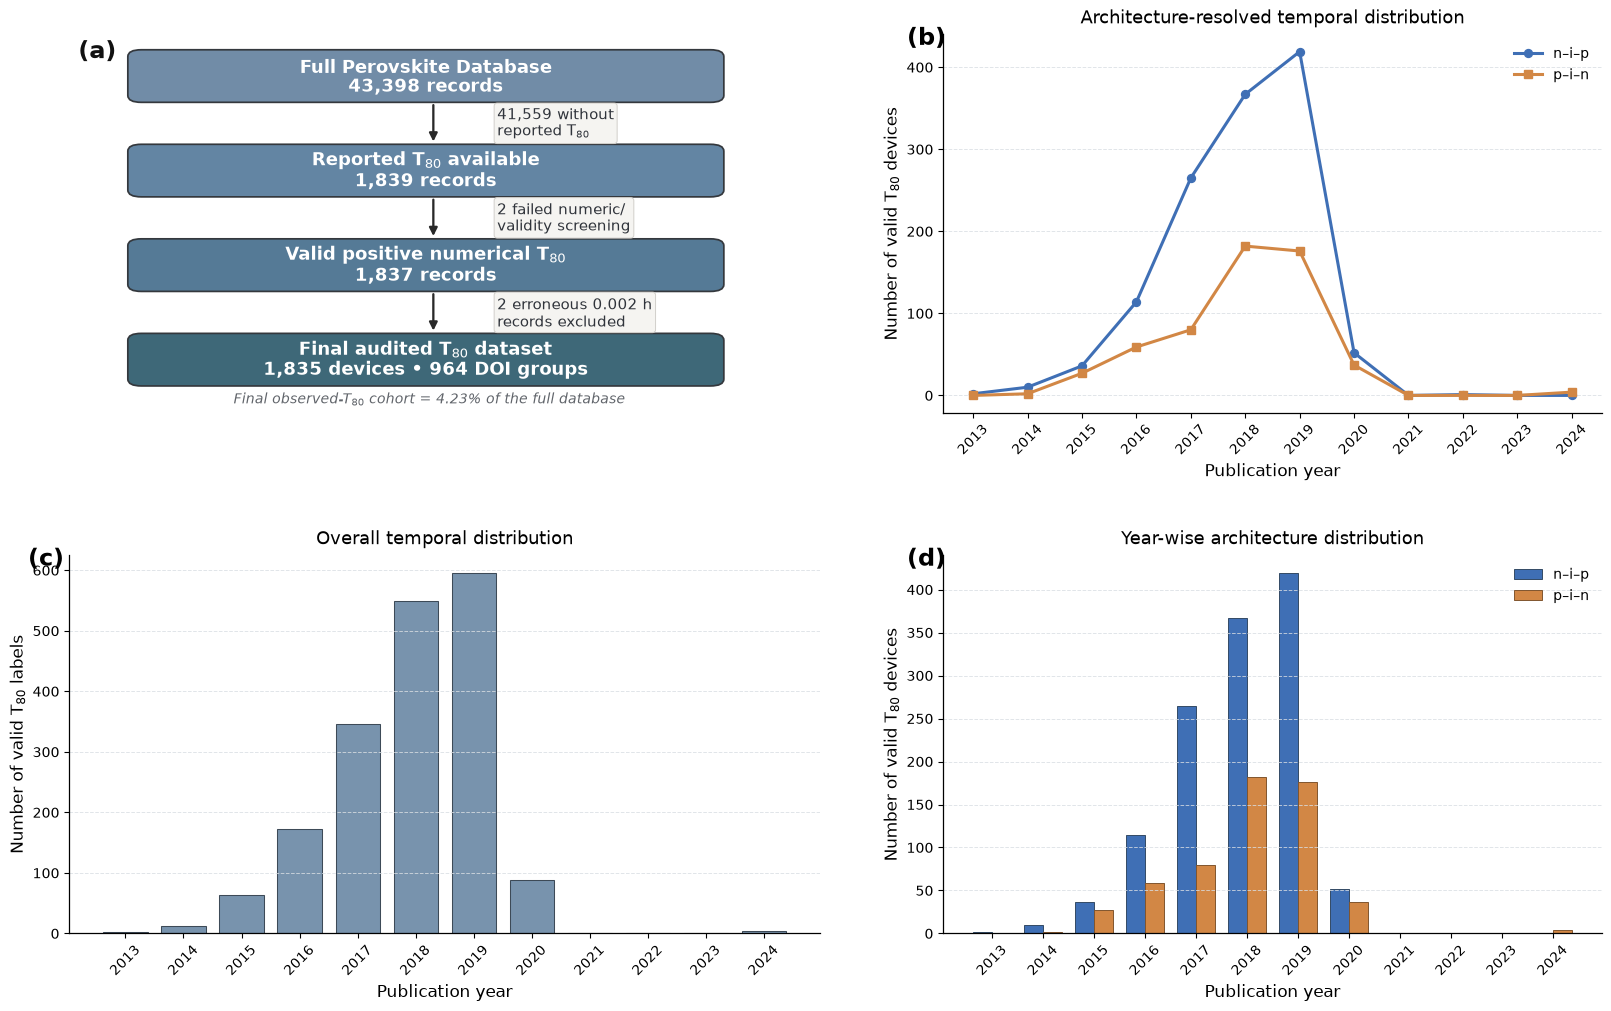

Saved:
C:\Users\khanm\OneDrive\Desktop\3rd model 18-03-2026\artifacts\01_labels\FigS2_T80_dataflow_temporal_FINAL.png
C:\Users\khanm\OneDrive\Desktop\3rd model 18-03-2026\artifacts\01_labels\FigS2_T80_dataflow_temporal_FINAL.pdf


In [28]:
# ============================================================
# FIGURE S2 — FINAL PUBLICATION-QUALITY VERSION
#
# (a) T80 dataset-construction flow
# (b) Architecture-resolved temporal trends
# (c) Overall temporal distribution
# (d) Architecture-resolved yearly counts
#
# Reviewer 2 — Comment 2
# ============================================================

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import FancyBboxPatch
from matplotlib.gridspec import GridSpec


# ============================================================
# 1. OUTPUT DIRECTORY
# ============================================================

if "ARTIFACT_DIR" not in globals():
    ARTIFACT_DIR = os.path.join(
        WORK_DIR,
        "artifacts"
    )

os.makedirs(
    ARTIFACT_DIR,
    exist_ok=True
)


# ============================================================
# 2. PREPARE DATA FROM FINAL AUDITED LABEL DATASET
# ============================================================

plot_df = labels_t80.copy()

plot_df["publication_year"] = pd.to_numeric(
    plot_df["publication_year"],
    errors="coerce"
)

plot_df = plot_df[
    plot_df["publication_year"].notna()
].copy()

plot_df["publication_year"] = (
    plot_df["publication_year"].astype(int)
)

# Normalize architecture labels
plot_df["architecture_norm"] = (
    plot_df["Cell_architecture"]
    .astype(str)
    .str.lower()
    .str.replace(
        r"[^a-z]",
        "",
        regex=True
    )
)

plot_df["architecture_plot"] = (
    plot_df["architecture_norm"]
    .map({
        "nip": "n–i–p",
        "pin": "p–i–n"
    })
)


# ============================================================
# 3. YEARLY COUNTS
# ============================================================

year_min = int(
    plot_df["publication_year"].min()
)

year_max = int(
    plot_df["publication_year"].max()
)

years = np.arange(
    year_min,
    year_max + 1
)

# Overall counts
overall_year_counts = (
    plot_df["publication_year"]
    .value_counts()
    .reindex(
        years,
        fill_value=0
    )
    .sort_index()
)

# Architecture-specific counts
arch_year_counts = (
    plot_df[
        plot_df["architecture_plot"].isin(
            ["n–i–p", "p–i–n"]
        )
    ]
    .groupby(
        [
            "publication_year",
            "architecture_plot"
        ]
    )
    .size()
    .unstack(
        fill_value=0
    )
    .reindex(
        years,
        fill_value=0
    )
)

for architecture in [
    "n–i–p",
    "p–i–n"
]:
    if architecture not in arch_year_counts.columns:
        arch_year_counts[architecture] = 0

arch_year_counts = arch_year_counts[
    [
        "n–i–p",
        "p–i–n"
    ]
]


# ============================================================
# 4. FLOW-DIAGRAM COUNTS
# ============================================================

raw_rows = 43398
reported_t80 = 1839
valid_numeric_t80 = 1837
final_t80 = 1835
final_doi = 964

retained_percent = (
    final_t80 / raw_rows
) * 100


# ============================================================
# 5. PUBLICATION PALETTE
# ============================================================

FLOW_COLORS = [
    "#718CA7",
    "#6385A3",
    "#557A96",
    "#3E6878"
]

# Architecture colors
NIP_COLOR = "#3F6FB5"
PIN_COLOR = "#D28745"

# Overall temporal bars
TOTAL_COLOR = "#7893AD"

GRID_COLOR = "#D9DEE3"
TEXT_COLOR = "#30343B"

NOTE_FACE = "#F5F4F1"
NOTE_EDGE = "#D1CFCA"


# ============================================================
# 6. GLOBAL STYLE
# ============================================================

plt.rcParams.update({
    "font.family": "sans-serif",
    "font.size": 11,
    "axes.titlesize": 13,
    "axes.labelsize": 12,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
    "legend.fontsize": 10,
    "axes.linewidth": 0.9,
    "savefig.dpi": 900
})


# ============================================================
# 7. CREATE FIGURE
# ============================================================

fig = plt.figure(
    figsize=(16, 10),
    constrained_layout=True
)

gs = GridSpec(
    2,
    2,
    figure=fig,
    width_ratios=[
        1.14,
        1.00
    ],
    height_ratios=[
        1.0,
        1.0
    ],
    wspace=0.08,
    hspace=0.10
)


# ============================================================
# PANEL (a) — DATASET-CONSTRUCTION FLOW
# ============================================================

ax1 = fig.add_subplot(
    gs[0, 0]
)

ax1.set_xlim(
    0,
    1
)

ax1.set_ylim(
    0,
    1
)

ax1.axis(
    "off"
)

# ------------------------------------------------------------
# Wide flow boxes
# ------------------------------------------------------------

box_x = 0.09
box_w = 0.77
box_h = 0.115

box_centers = [
    0.89,
    0.64,
    0.39,
    0.14
]

box_texts = [
    (
        "Full Perovskite Database\n"
        "43,398 records"
    ),
    (
        "Reported T$_{80}$ available\n"
        "1,839 records"
    ),
    (
        "Valid positive numerical T$_{80}$\n"
        "1,837 records"
    ),
    (
        "Final audited T$_{80}$ dataset\n"
        "1,835 devices • 964 DOI groups"
    )
]

for yc, text, color in zip(
    box_centers,
    box_texts,
    FLOW_COLORS
):

    y0 = yc - box_h / 2

    box = FancyBboxPatch(
        (
            box_x,
            y0
        ),
        box_w,
        box_h,
        boxstyle=(
            "round,pad=0.012,"
            "rounding_size=0.018"
        ),
        linewidth=1.25,
        edgecolor="#34383D",
        facecolor=color
    )

    ax1.add_patch(
        box
    )

    ax1.text(
        box_x + box_w / 2,
        yc,
        text,
        ha="center",
        va="center",
        fontsize=13.0,
        fontweight="semibold",
        color="white",
        linespacing=1.12
    )


# ------------------------------------------------------------
# Arrows
# ------------------------------------------------------------

arrow_x = 0.485

for upper_y, lower_y in zip(
    box_centers[:-1],
    box_centers[1:]
):

    ax1.annotate(
        "",
        xy=(
            arrow_x,
            lower_y + box_h / 2 + 0.012
        ),
        xytext=(
            arrow_x,
            upper_y - box_h / 2 - 0.012
        ),
        arrowprops=dict(
            arrowstyle="-|>",
            linewidth=1.65,
            color="#292929",
            mutation_scale=12
        ),
        zorder=2
    )


# ------------------------------------------------------------
# Removal annotations
# ------------------------------------------------------------

gap_centers = [
    (
        box_centers[0]
        + box_centers[1]
    ) / 2,
    (
        box_centers[1]
        + box_centers[2]
    ) / 2,
    (
        box_centers[2]
        + box_centers[3]
    ) / 2
]

gap_notes = [
    "41,559 without\nreported T$_{80}$",

    "2 failed numeric/\nvalidity screening",

    "2 erroneous 0.002 h\nrecords excluded"
]

for y_note, note in zip(
    gap_centers,
    gap_notes
):

    ax1.text(
        0.57,
        y_note,
        note,
        ha="left",
        va="center",
        fontsize=10.8,       # increased from 9.8
        color=TEXT_COLOR,
        linespacing=1.15,
        bbox=dict(
            boxstyle="round,pad=0.20",
            facecolor=NOTE_FACE,
            edgecolor=NOTE_EDGE,
            linewidth=0.7
        ),
        zorder=3
    )


# ------------------------------------------------------------
# Retention note
# ------------------------------------------------------------

ax1.text(
    0.48,
    0.015,
    (
        "Final observed-T$_{80}$ cohort = "
        f"{retained_percent:.2f}% "
        "of the full database"
    ),
    ha="center",
    va="bottom",
    fontsize=10.3,
    fontstyle="italic",
    color="#60646A"
)


# Panel label (a)
ax1.text(
    0.012,
    0.985,
    "(a)",
    transform=ax1.transAxes,
    ha="left",
    va="top",
    fontsize=17,
    fontweight="bold",
    color="#111111"
)


# ============================================================
# PANEL (b) — TEMPORAL TRENDS BY ARCHITECTURE
# ============================================================

ax2 = fig.add_subplot(
    gs[0, 1]
)

ax2.plot(
    years,
    arch_year_counts["n–i–p"],
    marker="o",
    markersize=5.7,
    linewidth=2.2,
    color=NIP_COLOR,
    label="n–i–p"
)

ax2.plot(
    years,
    arch_year_counts["p–i–n"],
    marker="s",
    markersize=5.4,
    linewidth=2.2,
    color=PIN_COLOR,
    label="p–i–n"
)

ax2.set_title(
    "Architecture-resolved temporal distribution",
    pad=8
)

ax2.set_xlabel(
    "Publication year"
)

ax2.set_ylabel(
    "Number of valid T$_{80}$ devices"
)

ax2.set_xticks(
    years
)

ax2.tick_params(
    axis="x",
    rotation=45
)

ax2.grid(
    axis="y",
    linestyle="--",
    linewidth=0.7,
    color=GRID_COLOR,
    alpha=0.8
)

# Legend moved to upper-right
ax2.legend(
    frameon=False,
    loc="upper right"
)

ax2.spines[
    "top"
].set_visible(False)

ax2.spines[
    "right"
].set_visible(False)

# Panel label moved slightly outside axes
ax2.text(
    -0.055,
    1.02,
    "(b)",
    transform=ax2.transAxes,
    ha="left",
    va="top",
    fontsize=17,
    fontweight="bold"
)


# ============================================================
# PANEL (c) — OVERALL TEMPORAL DISTRIBUTION
# ============================================================

ax3 = fig.add_subplot(
    gs[1, 0]
)

ax3.bar(
    years,
    overall_year_counts.values,
    width=0.76,
    color=TOTAL_COLOR,
    edgecolor="#3D4A57",
    linewidth=0.75
)

ax3.set_title(
    "Overall temporal distribution",
    pad=8
)

ax3.set_xlabel(
    "Publication year"
)

ax3.set_ylabel(
    "Number of valid T$_{80}$ labels"
)

ax3.set_xticks(
    years
)

ax3.tick_params(
    axis="x",
    rotation=45
)

ax3.grid(
    axis="y",
    linestyle="--",
    linewidth=0.7,
    color=GRID_COLOR,
    alpha=0.8
)

ax3.spines[
    "top"
].set_visible(False)

ax3.spines[
    "right"
].set_visible(False)

# Panel label moved slightly outside axes
ax3.text(
    -0.055,
    1.02,
    "(c)",
    transform=ax3.transAxes,
    ha="left",
    va="top",
    fontsize=17,
    fontweight="bold"
)


# ============================================================
# PANEL (d) — ARCHITECTURE-RESOLVED YEARLY COUNTS
# ============================================================

ax4 = fig.add_subplot(
    gs[1, 1]
)

x = np.arange(
    len(years)
)

bar_width = 0.37

ax4.bar(
    x - bar_width / 2,
    arch_year_counts["n–i–p"],
    width=bar_width,
    color=NIP_COLOR,
    edgecolor="#334A65",
    linewidth=0.7,
    label="n–i–p"
)

ax4.bar(
    x + bar_width / 2,
    arch_year_counts["p–i–n"],
    width=bar_width,
    color=PIN_COLOR,
    edgecolor="#80552E",
    linewidth=0.7,
    label="p–i–n"
)

ax4.set_title(
    "Year-wise architecture distribution",
    pad=8
)

ax4.set_xlabel(
    "Publication year"
)

ax4.set_ylabel(
    "Number of valid T$_{80}$ devices"
)

ax4.set_xticks(
    x
)

ax4.set_xticklabels(
    years,
    rotation=45
)

ax4.grid(
    axis="y",
    linestyle="--",
    linewidth=0.7,
    color=GRID_COLOR,
    alpha=0.8
)

# Legend moved to upper-right
ax4.legend(
    frameon=False,
    loc="upper right"
)

ax4.spines[
    "top"
].set_visible(False)

ax4.spines[
    "right"
].set_visible(False)

# Panel label moved slightly outside axes
ax4.text(
    -0.055,
    1.02,
    "(d)",
    transform=ax4.transAxes,
    ha="left",
    va="top",
    fontsize=17,
    fontweight="bold"
)


# ============================================================
# 8. SAVE
#
# No plt.tight_layout()
# constrained_layout handles spacing
# ============================================================

png_file = os.path.join(
    ARTIFACT_DIR,
    "FigS2_T80_dataflow_temporal_FINAL.png"
)

pdf_file = os.path.join(
    ARTIFACT_DIR,
    "FigS2_T80_dataflow_temporal_FINAL.pdf"
)

plt.savefig(
    png_file,
    dpi=900,
    bbox_inches="tight",
    facecolor="white"
)

plt.savefig(
    pdf_file,
    bbox_inches="tight",
    facecolor="white"
)

plt.show()

print("Saved:")
print(png_file)
print(pdf_file)